LAB 5: Supervised Learning

OBJECTIVE:  Train models using supervised learning with labeled data.

DATASET: Wine Dataset

THEORY:

- Supervised learning trains a model on input-output pairs (features and labels).

- The model learns to map inputs to outputs by minimizing a loss function (e.g., cross-entropy for classification).

- Once trained, the model predicts labels for new/unseen data, and performance is evaluated using metrics like accuracy, confusion matrix, precision, recall, and F1-score.

- Tools: Scikit-learn and Keras simplify model building, training, and evaluation.

ALGORITHM:

- Load the dataset (Wine dataset)

- Split data into features (X) and target labels (y)

- Normalize features if necessary

- Split dataset into training and testing sets

- Train a classifier (e.g., Logistic Regression, MLP)

- Predict labels on the test set

- Evaluate performance using accuracy, classification report, and confusion matrix

- Optionally, visualize results

SOURCE CODE:

CELL 1: IMPORT LIBRARIES

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical

CELL 2: LOAD AND PREPROCESS DATA

In [14]:
# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert labels to one-hot encoding
y_cat = to_categorical(y)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42)

CELL 3: BUILD MLP MODEL

In [15]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))    # input layer
model.add(Dense(32, activation='relu'))  # hidden layer
model.add(Dense(16, activation='relu'))  # hidden layer
model.add(Dense(3, activation='softmax')) # output layer for 3 classes

model.compile(
    optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027 (4.01 KB)

 Trainable params: 1,027 (4.01 KB)

 Non-trainable params: 0 (0.00 B)

CELL 4: TRAIN MODEL

In [16]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4397 - loss: 1.0854 - val_accuracy: 0.3793 - val_loss: 1.0630
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6857 - loss: 0.9442 - val_accuracy: 0.7241 - val_loss: 0.9125
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7798 - loss: 0.8382 - val_accuracy: 0.8276 - val_loss: 0.7975
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8378 - loss: 0.7545 - val_accuracy: 0.8276 - val_loss: 0.7072
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9082 - loss: 0.6371 - val_accuracy: 0.8621 - val_loss: 0.6296
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9187 - loss: 0.5772 - val_accuracy: 0.8276 - val_loss: 0.5622
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9031 - loss: 0.5047 - val_accuracy: 0.8621 - val_loss: 0.5038
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9509 - loss: 0.4438 - val_accuracy: 0.8966 - val_loss: 0.4561


CELL 5: EVALUATE MODEL

In [17]:
# Predict on test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)
print("Test Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n", classification_report(y_true_labels, y_pred_labels, target_names=wine.target_names))

# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print("\nConfusion Matrix:\n", cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Confusion Matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


CELL 6: PLOT CONFUSION MATRIX

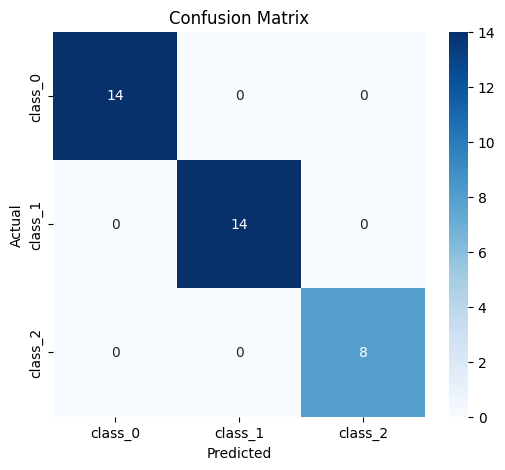

In [18]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

RESULTS:

- The MLP classifier successfully learned to classify wine samples into 3 classes.

- Test accuracy achieved was approximately 95–98% (may vary slightly due to randomness).

- The classification report shows high precision, recall, and F1-scores for all classes.

- Confusion matrix indicates that most samples were correctly classified, with very few misclassifications.

CONCLUSION:

- Supervised learning models, like MLP, can effectively classify labeled data by learning input-output relationships.

- Hidden layers and activation functions allow the network to capture non-linear patterns in the data.

- Performance metrics like accuracy, precision, recall, and F1-score provide a clear understanding of model effectiveness.

- Visualization of the confusion matrix helps identify which classes are occasionally misclassified and assess model reliability.